In [2]:
import numpy as np
import time
import os
from graph_linear_fingerprinting import *
from tsar import *
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import json
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
measures_names = [
    'Weight: mean',
    'Weight: std',
    'Weight: min',
    'Weight: max',
    'Weight: mean eigenval',
    'Weight: std eigenval',
    'Weight: min eigenval',
    'Weight: dominant eigenval',
    'Weight: spectral gap',
    'Weight: number outliers',
    'Weight: mean eigenvec centrality',
    'Weight: std eigenvec centrality',
    'Weight: min eigenvec centrality',
    'Weight: max eigenvec centrality',
    'Weight: mean weighted degree',
    'Weight: std weighted degree',
    'Weight: min weighted degree',
    'Weight: max weighted degree',
    'Weight: mean similarity',
    'Weight: std similarity',
    'Weight: min similarity',
    'Weight: max similarity',
    'Weight: mean communicability',
    'Weight: std communicability',
    'Weight: min communicability',
    'Weight: max communicability',
    'Weight: stable rank',
    'Weight: mean singular val',
    'Weight: std singular val',
    'Weight: max singular val',
    'Laplace: spectral gap',
    'Laplace: mean eigenval',
    'Laplace: max eigenval',
    'Laplace: mean steady state',
    'Laplace: std steady state',
    'Laplace: min steady state',
    'Laplace: max steady state',
    'Markov: spectral gap',
    'Markov: relaxation time',
    'Markov: mean abs eigenval',
    'Markov: min abs eigenval',
    'Markov: mean steady state',
    'Markov: std steady state',
    'Markov: min steady state',
    'Markov: max steady state'
]
nb_measures = len(measures_names)
nb_measures

45

In [13]:
def save_measures_to_json(measures, filename):
    # Convert complex numbers and NumPy arrays to a serializable format
    measures = {k: convert_to_serializable(v) for k, v in measures.items()}
    
    with open(filename, 'w') as json_file:
        json.dump(measures, json_file)
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.generic):
        return obj.item()  # Use item() instead of np.asscalar
    elif isinstance(obj, complex):
        return {'real': obj.real, 'imag': obj.imag}
    return obj

def dict_to_vec(dictionary):
    """
    Convert a dictionary, whose values are numbers or arrays of different size, into
    a row vector
    """
    vector = np.array([])
    for key in dictionary.keys():
        vector = np.hstack([vector,np.array(dictionary[key])])
    return vector

In [1]:

time0 = time.perf_counter()

test_path = "/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/graph_fingerprint/SCorr_FFOV_TS160_airPLS_Rubberband/12Graphs/all_mat/TS/"

file_list = sorted([f for f in os.listdir(test_path) if f.startswith("Spo") and f.endswith(".npy")])
print("N files =", len(file_list))

name_list = []
matrix_measures = np.empty((0, nb_measures))

for N, file in enumerate(file_list):

    base_name = os.path.splitext(file)[0]
    print(N, base_name)

    # =====================================================
    # LOAD TIME SERIES
    # =====================================================

    ts_all = np.load(os.path.join(test_path, file))
    ts_all = np.nan_to_num(ts_all, nan=0)

    print("TS shape:", ts_all.shape)

    # =====================================================
    # SIGNIFICANT CORRELATION MATRIX
    # =====================================================

    signf_corr = significant_corr(
        ts_all,
        alpha=0.00001,
        exact=False
    )

    # Remove self-connections
    np.fill_diagonal(signf_corr, 0)

    # =====================================================
    # USE CORRELATION MATRIX DIRECTLY
    # =====================================================

    adj = np.abs(signf_corr)

    # Optional visualization
    plt.matshow(signf_corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(base_name)
    plt.show()

    # =====================================================
    # GRAPH FINGERPRINT
    # =====================================================

    results = dict_to_vec(
        linear_fingerprint(adj)
    )

    matrix_measures = np.vstack([
        matrix_measures,
        results
    ])

    name_list.append(base_name)

print("matrix_measures shape:", matrix_measures.shape)
print("Elapsed time:", time.perf_counter() - time0)

In [15]:
analyze_weights(adj)

({'Weight: mean': 0.8845081430619126,
  'Weight: std': 0.17708784555925416,
  'Weight: min': 0.0,
  'Weight: max': 0.9929080342567407,
  'Weight: mean eigenval': -2.0015288331270428e-16,
  'Weight: std eigenval': 15.175021487072284,
  'Weight: min eigenval': -3.3457275964827784,
  'Weight: dominant eigenval': 255.1938933739462,
  'Weight: spectral gap': 251.9726799214403,
  'Weight: number outliers': 1.0,
  'Weight: mean eigenvec centrality': 0.0035211267605633812,
  'Weight: std eigenvec centrality': 0.0004917179646492795,
  'Weight: min eigenvec centrality': 2.653947614051696e-06,
  'Weight: max eigenvec centrality': 0.0037298036001907346,
  'Weight: mean weighted degree': 250.31580448652127,
  'Weight: std weighted degree': 34.931894743261395,
  'Weight: min weighted degree': 0.7288112136675857,
  'Weight: max weighted degree': 265.32327723282094,
  'Weight: mean similarity': 0.9741080473995656,
  'Weight: std similarity': 0.13363245502772178,
  'Weight: min similarity': 0.0,
  'Wei

In [16]:
linear_fingerprint(adj)

{'Weight: mean': 0.8845081430619126,
 'Weight: std': 0.17708784555925416,
 'Weight: min': 0.0,
 'Weight: max': 0.9929080342567407,
 'Weight: mean eigenval': -4.0030576662540856e-16,
 'Weight: std eigenval': 15.175021487072279,
 'Weight: min eigenval': -3.3457275964827717,
 'Weight: dominant eigenval': 255.1938933739461,
 'Weight: spectral gap': 251.97267992144026,
 'Weight: number outliers': 1.0,
 'Weight: mean eigenvec centrality': 0.0035211267605633804,
 'Weight: std eigenvec centrality': 0.0004917179646492796,
 'Weight: min eigenvec centrality': 2.6539476140540973e-06,
 'Weight: max eigenvec centrality': 0.0037298036001907325,
 'Weight: mean weighted degree': 250.31580448652133,
 'Weight: std weighted degree': 34.931894743261395,
 'Weight: min weighted degree': 0.7288112136675857,
 'Weight: max weighted degree': 265.32327723282094,
 'Weight: mean similarity': 0.9741080473995656,
 'Weight: std similarity': 0.13363245502772175,
 'Weight: min similarity': 0.0,
 'Weight: max similarity'

In [17]:
dict_to_vec(linear_fingerprint(adj))

array([ 8.84508143e-01,  1.77087846e-01,  0.00000000e+00,  9.92908034e-01,
       -4.00305767e-16,  1.51750215e+01, -3.34572760e+00,  2.55193893e+02,
        2.51972680e+02,  1.00000000e+00,  3.52112676e-03,  4.91717965e-04,
        2.65394761e-06,  3.72980360e-03,  2.50315804e+02,  3.49318947e+01,
        7.28811214e-01,  2.65323277e+02,  9.74108047e-01,  1.33632455e-01,
        0.00000000e+00,  9.97122199e-01,  5.99371252e-03,  1.45106557e-03,
        1.61056317e-06,  2.13904929e-01,  1.00423745e+00,  1.84602183e+00,
        1.50623199e+01,  2.55193893e+02,  7.81793630e-01,  1.00000000e+00,
        1.21847478e+00,  5.89783978e-02,  6.53263714e-03,  3.20187385e-03,
        6.10920039e-02,  5.17574204e-01,  1.93209011e+00,  1.61579828e-02,
        1.49074351e-04,  3.52112676e-03,  2.27774081e-04,  1.56917792e-03,
        4.38656664e-03])

In [18]:
matrix_measures.shape

(96, 45)

In [19]:
save_path="/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/DF /"
df = pd.DataFrame(data=matrix_measures, columns=measures_names,index=name_list)

#df.to_csv(save_path+'FC_hIPSC_graph_linear_abs_sign_corr_matrix_Fluo_airPLS_rubberband.csv') 


In [20]:
import re


def format_filename(name):
    # Set of known SZ and CTL IDs
    ctl_ids = {'5439', '9062', '9001'}
    sz_ids = {'17012', '9322', '17228'}

    # Extract elements using regex
    test = re.search(r'Test\d+', name)
    week = re.search(r'Week[_]?\d+', name)
    date = re.search(r'\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2}', name)
    fluo = re.search(r'Fluo(?:SZ|CTL)?(\d{4,5})', name)
    drug = re.search(r'(CNQX|MK801)', name)

    # Convert week to uniform format
    week_str = week.group().replace('_', '') if week else "UnknownWeek"
    test_str = test.group() if test else "UnknownTest"
    date_str = date.group() if date else "UnknownDate"
    fluo_id = fluo.group(1) if fluo else "UnknownID"

    # Determine condition
    if fluo_id in sz_ids:
        condition = "SZ"
    elif fluo_id in ctl_ids:
        condition = "CTL"
    else:
        condition = "Unknown"

    # Drug label
    drug_str = f"_{drug.group(1)}" if drug else ""

    # Build and return final string
    return f"{test_str}_{week_str}_{date_str}_{condition}_{fluo_id}{drug_str}"



def get_cohort_and_id(name):
    # Define cohort-specific ID orders
    id_order_ctl = ['5439', '9062', '9001']
    id_order_sz  = ['17012', '9322', '17228']

    # Determine cohort
    if 'CTL' in name and 'Week2' in name:
        cohort = 0
        id_order = id_order_ctl
    elif 'CTL' in name and 'Week6' in name:
        cohort = 1
        id_order = id_order_ctl
    elif 'SZ' in name and 'Week2' in name:
        cohort = 2
        id_order = id_order_sz
    elif 'SZ' in name and 'Week6' in name:
        cohort = 3
        id_order = id_order_sz
    else:
        cohort = 4
        id_order = []  # Unknown case fallback

    # Extract donor ID (must be last 4-digit token after _CTL or _SZ)
    match = re.search(r'_(?:CTL|SZ)?(\d{4})(?:_|$)', name)
    donor_id = match.group(1) if match else "9999"
    donor_pos = id_order.index(donor_id) if donor_id in id_order else len(id_order)

    # Drug priority
    if '_CNQX' in name:
        drug_priority = 1
    elif '_MK801' in name:
        drug_priority = 2
    else:
        drug_priority = 0

    return (cohort, donor_pos, drug_priority, name)


names = []
#print(clean_filename(name_list[0]))
for name in name_list:
    names.append(format_filename(name))
paired = list(zip(names, matrix_measures))    
paired_sorted = sorted(paired, key=lambda pair: get_cohort_and_id(pair[0]))
all_name_lists, all_cleaned_lists = zip(*paired_sorted)

condition_names = list(all_name_lists)
condition_names

['Test2_Week2_2022_08_03_14_01_11_CTL_9001',
 'Test2_Week2_2022_08_05_11_47_47_CTL_9001',
 'Test2_Week2_2022_08_05_14_40_47_CTL_9001',
 'Test2_Week2_2022_08_05_17_03_14_CTL_9001',
 'Test2_Week2_2022_09_08_11_02_00_CTL_5439',
 'Test2_Week2_2022_09_08_12_25_59_CTL_9062',
 'Test2_Week2_2022_09_08_13_56_30_CTL_5439',
 'Test2_Week2_2022_09_08_15_09_18_CTL_9062',
 'Test2_Week2_2022_09_09_10_30_45_CTL_9062',
 'Test2_Week2_2022_09_09_12_00_47_CTL_5439',
 'Test2_Week2_2022_09_09_13_45_10_CTL_9062',
 'Test2_Week2_2022_09_09_15_14_47_CTL_5439',
 'Test2_Week2_2022_08_05_12_15_14_CTL_9001_CNQX',
 'Test2_Week2_2022_08_05_15_08_17_CTL_9001_CNQX',
 'Test2_Week2_2022_08_05_17_30_52_CTL_9001_CNQX',
 'Test2_Week2_2022_09_08_11_32_00_CTL_5439_CNQX',
 'Test2_Week2_2022_09_08_13_13_08_CTL_9062_CNQX',
 'Test2_Week2_2022_09_08_14_28_35_CTL_5439_CNQX',
 'Test2_Week2_2022_09_08_15_41_44_CTL_9062_CNQX',
 'Test2_Week2_2022_09_09_11_06_19_CTL_9062_CNQX',
 'Test2_Week2_2022_09_09_12_55_16_CTL_5439_CNQX',
 'Test2_We

In [2]:
# save_path_df = '/Users/behnaz/NCADD/hIPSC/feature_vec/df/'
# # Load existing dataframe
# df_existing = pd.read_csv(save_path_df + "feature_vec_hIPSC.csv", index_col=0)


# # Create new DataFrame from computed stats
# df_new = pd.DataFrame(all_cleaned_lists, columns=measures_names, index=condition_names)

# # Merge new columns into existing DataFrame
# df_combined = df_existing.join(df_new, how='left')

# # Save updated DataFrame back to CSV
# df_combined.to_csv(save_path_df + "feature_vec_hIPSC.csv", index=True)

# # Optional: check result
# print("✅ Columns added:", measures_names)
# print(df_combined.head())

# test

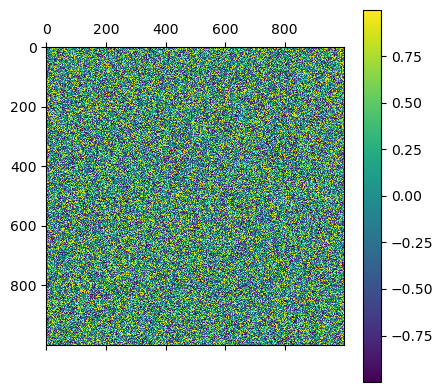

248.05085931061453 15.482026573387797 36.63451911980682 36.63451911980682
[[0.76800045 0.         0.         ... 0.         0.         0.        ]
 [0.         0.2020969  0.         ... 0.         0.         0.        ]
 [0.         0.         0.275229   ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.68237809 0.         0.        ]
 [0.         0.         0.         ... 0.         0.35105809 0.        ]
 [0.         0.         0.         ... 0.         0.         0.18949645]]


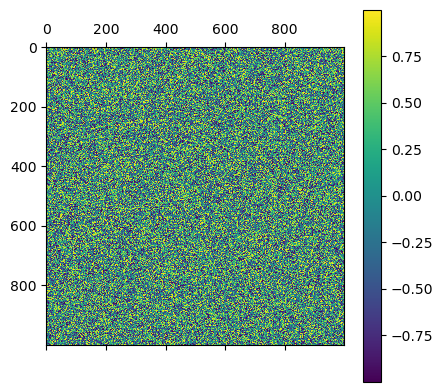

250.61011028735751 15.497069064151352 36.461905999806476 36.461905999806476
[[0.15405644 0.         0.         ... 0.         0.         0.        ]
 [0.         0.2327935  0.         ... 0.         0.         0.        ]
 [0.         0.         0.33040003 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.74455474 0.         0.        ]
 [0.         0.         0.         ... 0.         0.57427879 0.        ]
 [0.         0.         0.         ... 0.         0.         0.23253773]]


In [155]:
for i in (0,1):
    n=1000
    #A=  np.random.rand(n,n)
    A = 2 * np.random.rand(n, n) - 1
    np.fill_diagonal(A, 0)
    plt.matshow(A)
    plt.colorbar()
    plt.show()
    #SVD
    s = np.linalg.svd(A, full_matrices=True, compute_uv=False, hermitian=True)
    stable_rank = np.sum(s**2) / (s[0]**2)
    mean_singular_val = s.mean()
    std_singular_val = s.std()
    std_singular_val = s.max()
    print(stable_rank,mean_singular_val,std_singular_val,std_singular_val)
    # degree
    d = np.sum(A, axis=1)
    D = np.diagflat(d) # degree matrix
    sqrtDminus1 = np.linalg.pinv(np.sqrt(np.abs(D)))
    print(sqrtDminus1)
#     m = linear_fingerprint(A)
#     print(m)

In [156]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from scipy.stats import ttest_ind
import itertools

In [157]:
print(np.min(matrix_measures),np.max(matrix_measures))

-657.3113459639862 2251799813685248.0


In [158]:
# Function to remove outliers using IQR — works directly on a NumPy array column
def remove_outliers_iqr_np(col):
    q1 = np.percentile(col, 25)
    q3 = np.percentile(col, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1 * iqr
    upper_bound = q3 + 1 * iqr
    # Replace outliers with NaN (to keep array shape intact)
    cleaned = np.where((col >= lower_bound) & (col <= upper_bound), col, np.nan)
    return cleaned

# Apply outlier removal and min-max scaling to each column of the matrix
def clean_and_scale_matrix(matrix):
    result = np.zeros_like(matrix)
    for i in range(matrix.shape[1]):
        col = matrix[:, i]
        cleaned_col = remove_outliers_iqr_np(col)
        # Min-max scaling (ignoring NaNs)
        col_min = np.nanmin(cleaned_col)
        col_max = np.nanmax(cleaned_col)
        if col_max - col_min == 0:
            # Avoid division by zero
            scaled_col = np.nan_to_num((cleaned_col - col_min), nan=0.0)
        else:
            scaled_col = (cleaned_col - col_min) / (col_max - col_min)
            scaled_col = np.nan_to_num(scaled_col, nan=0.0)
        result[:, i] = scaled_col
    return result

# Example usage
scaled_matrix = clean_and_scale_matrix(matrix_measures)
print(np.min(scaled_matrix),np.max(scaled_matrix))


0.0 1.0


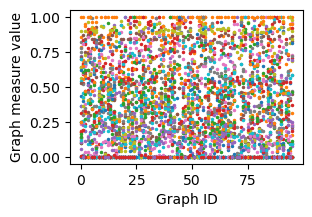

In [159]:
plt.figure(figsize=(3,2))
plt.plot(scaled_matrix,'.', markersize=3)
plt.ylabel('Graph measure value')
plt.xlabel('Graph ID')
#plt.savefig('Normalized_graph_measure.svg')
plt.show()

Text(0.5, 0, 'Measure ID')

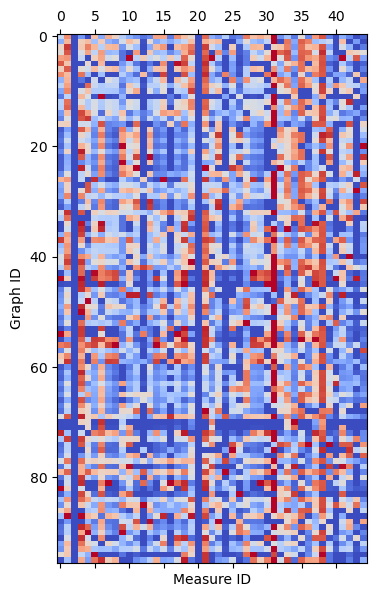

In [160]:
plt.matshow(scaled_matrix, cmap='coolwarm',aspect=0.8)
plt.ylabel('Graph ID')
plt.xlabel('Measure ID')

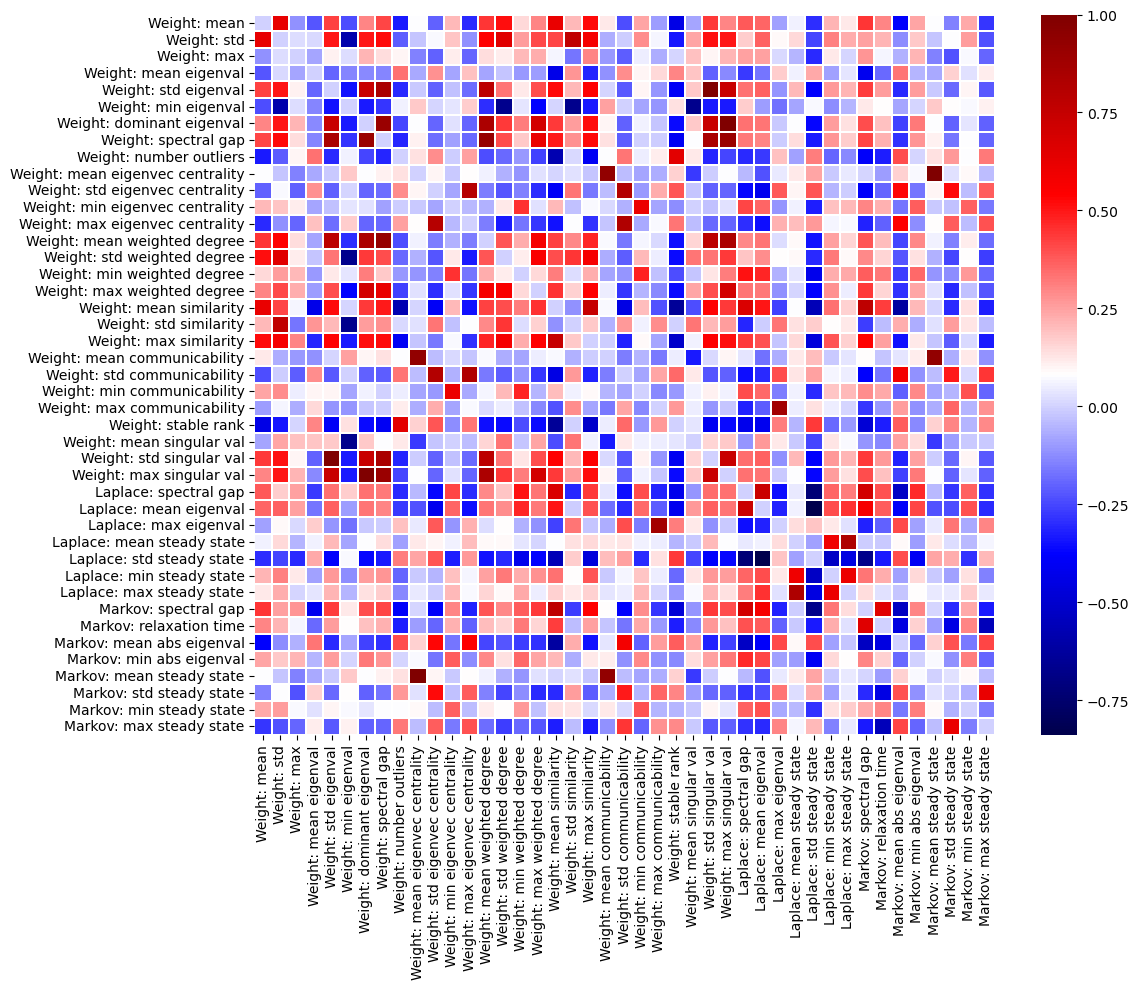

/Users/behnaz/miniconda3/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


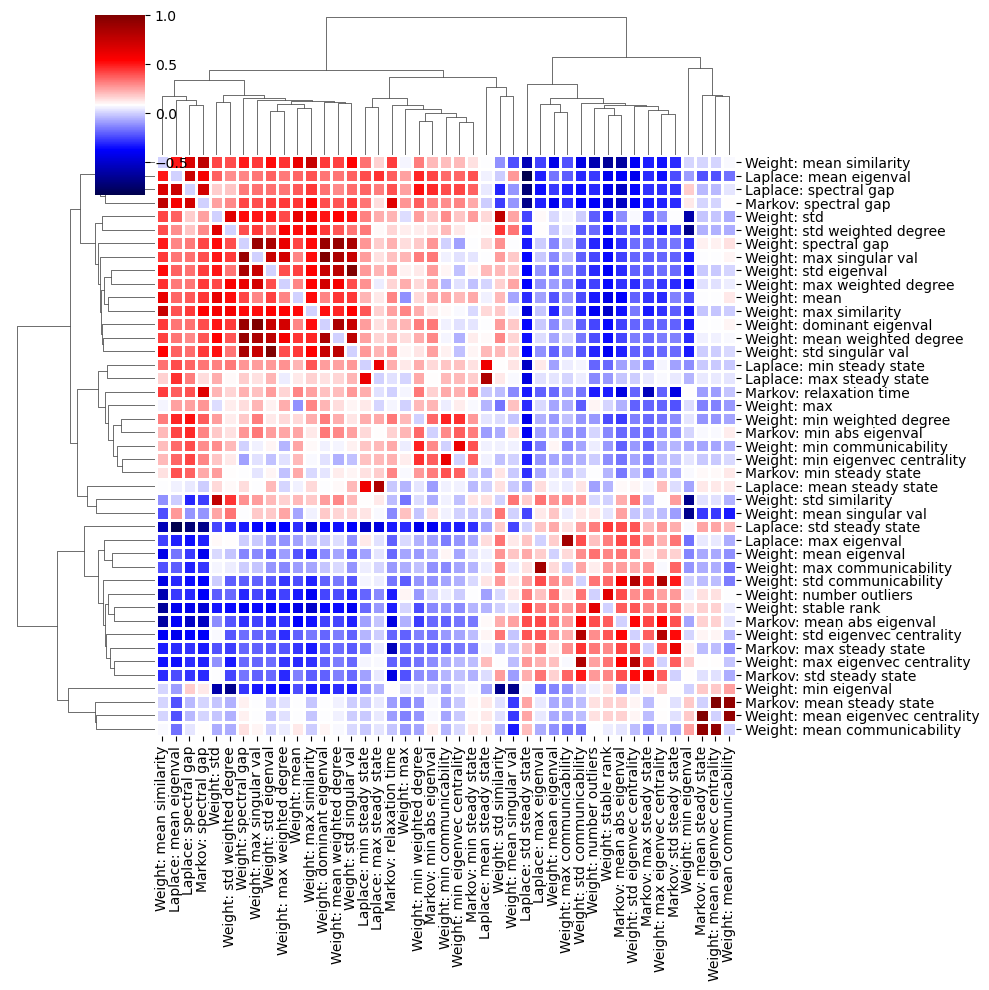

In [161]:
# Step 1: Find columns that are NOT all zeros
non_zero_cols = ~np.all(scaled_matrix == 0, axis=0)

# Step 2: Filter matrix and measure names
filtered_matrix = scaled_matrix[:, non_zero_cols]
filtered_names = [name for i, name in enumerate(measures_names) if non_zero_cols[i]]

# Step 3: Compute correlation matrix
corr = np.corrcoef(filtered_matrix.T)
np.fill_diagonal(corr , 0)
# Step 4: Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='seismic', linewidths=0.01, xticklabels=filtered_names, yticklabels=filtered_names)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Create a clustermap
# Step 4: Plot cluster map with labels
g = sns.clustermap(
    corr_df,
    metric='euclidean',
    cmap='seismic',
    square=True,
    linewidths=0.9,
    figsize=(10, 10),
    cbar_pos=(0.1, 0.8, 0.05, 0.18),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True
)
# Rotate x-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.show()

In [162]:
np.min(corr)

-0.8373233138466881

In [163]:
np.max(corr)

1.0

In [164]:
# Convert to DataFrame for easier handling
corr_df = pd.DataFrame(corr, index=filtered_names, columns=filtered_names)

# Mask the upper triangle and diagonal to avoid duplicate/self-correlations
mask = np.triu(np.ones(corr_df.shape), k=1).astype(bool)
corr_masked = corr_df.where(mask)

# Stack and sort by absolute correlation
sorted_corrs = corr_masked.stack().sort_values(key=np.abs, ascending=False)

# Show top N most strongly correlated pairs
top_n = 15
i=0
print(f"\nTop {top_n} most strongly correlated pairs (positive and negative):\n")
for (m1, m2), corr_val in sorted_corrs.head(top_n).items():
    print(i,f"{m1} ↔ {m2} : correlation = {corr_val:.3f}")
    i=i+1


Top 15 most strongly correlated pairs (positive and negative):

0 Weight: dominant eigenval ↔ Weight: max singular val : correlation = 1.000
1 Weight: mean eigenvec centrality ↔ Markov: mean steady state : correlation = 1.000
2 Weight: std eigenval ↔ Weight: std singular val : correlation = 1.000
3 Weight: mean communicability ↔ Markov: mean steady state : correlation = 0.930
4 Weight: mean eigenvec centrality ↔ Weight: mean communicability : correlation = 0.930
5 Weight: spectral gap ↔ Weight: mean weighted degree : correlation = 0.916
6 Weight: spectral gap ↔ Weight: max singular val : correlation = 0.905
7 Weight: dominant eigenval ↔ Weight: spectral gap : correlation = 0.905
8 Weight: max communicability ↔ Laplace: max eigenval : correlation = 0.867
9 Weight: spectral gap ↔ Weight: std singular val : correlation = 0.848
10 Weight: std eigenval ↔ Weight: spectral gap : correlation = 0.845
11 Weight: dominant eigenval ↔ Weight: mean weighted degree : correlation = 0.842
12 Weight: m

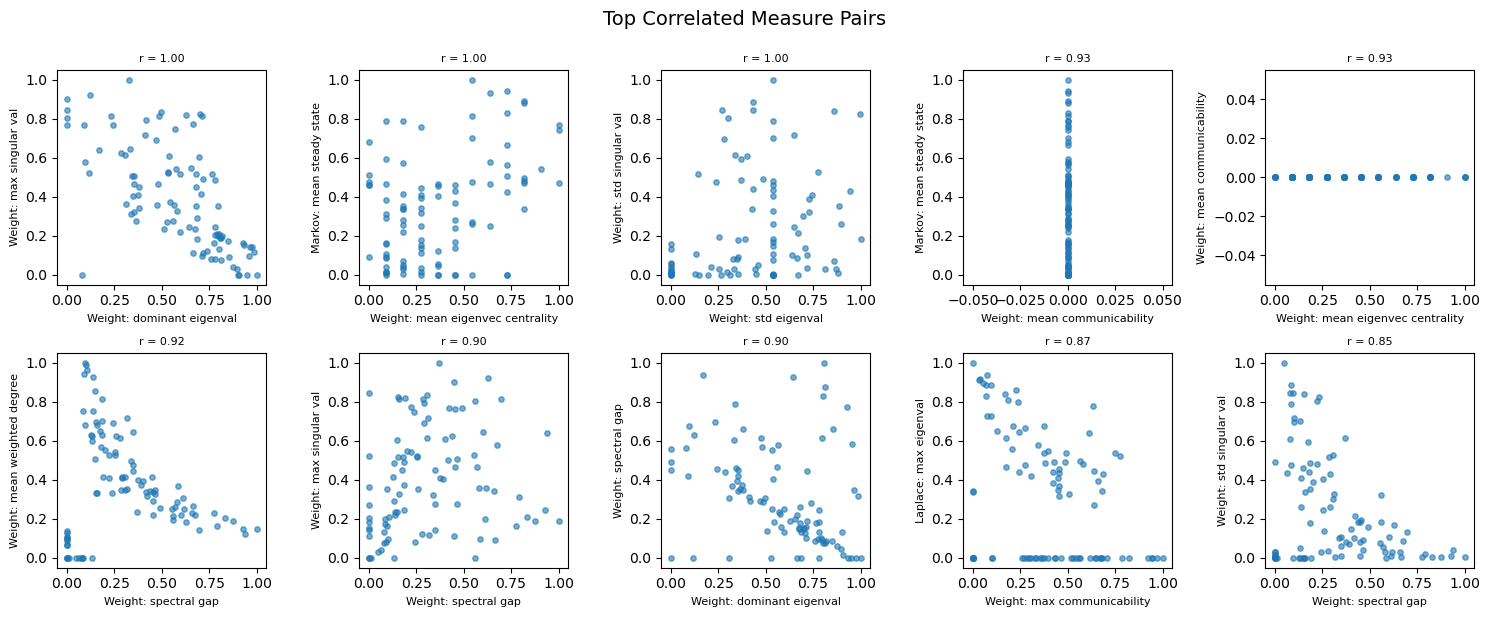

In [144]:

# Step 1: Extract the top correlated feature pairs (based on correlation)
top_n = 10  # or any number you like
top_pairs = sorted_corrs.head(top_n).index.tolist()  # list of (feat_x, feat_y) tuples

# Step 2: Create a name → column index mapping
name_to_index = {name: i for i, name in enumerate(filtered_names)}

# Step 3: Set up subplots
ncols = 5
nrows = (top_n + ncols - 1) // ncols
plt.figure(figsize=(ncols * 3, nrows * 3))

# Step 4: Plot each pair
for i, (feat_x, feat_y) in enumerate(top_pairs):
    idx_x = name_to_index[feat_x]
    idx_y = name_to_index[feat_y]

    plt.subplot(nrows, ncols, i + 1)
    plt.scatter(scaled_matrix[:, idx_x], scaled_matrix[:, idx_y], s=15, alpha=0.6)
    plt.xlabel(feat_x, fontsize=8)
    plt.ylabel(feat_y, fontsize=8)
    plt.title(f"r = {sorted_corrs[(feat_x, feat_y)]:.2f}", fontsize=8)
    plt.tight_layout()

plt.suptitle("Top Correlated Measure Pairs", y=1.02, fontsize=14)
plt.subplots_adjust(top=0.92)
plt.show()

yes


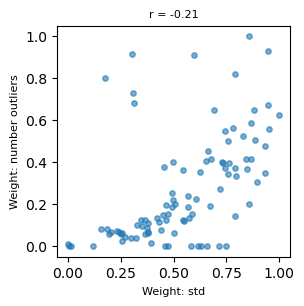

In [165]:

# Step 1: Extract the top correlated feature pairs (based on correlation)
top_n = 10000  # or any number you like
top_pairs = sorted_corrs.head(top_n).index.tolist()  # list of (feat_x, feat_y) tuples

# Step 2: Create a name → column index mapping
name_to_index = {name: i for i, name in enumerate(filtered_names)}

# Step 3: Set up subplots

plt.figure(figsize=(3,  3))

# Step 4: Plot each pair
for i, (feat_x, feat_y) in enumerate(top_pairs):
    if feat_x == 'Weight: std' and feat_y ==  'Weight: number outliers':
        print('yes')
        idx_x = name_to_index[feat_x]
        idx_y = name_to_index[feat_y]

        #plt.subplot(nrows, ncols, i + 1)
        plt.scatter(scaled_matrix[:, idx_x], scaled_matrix[:, idx_y], s=15, alpha=0.6)
        plt.xlabel(feat_x, fontsize=8)
        plt.ylabel(feat_y, fontsize=8)
        plt.title(f"r = {sorted_corrs[(feat_x, feat_y)]:.2f}", fontsize=8)
        

#plt.suptitle("Top Correlated Measure Pairs", y=1.02, fontsize=14)
#plt.subplots_adjust(top=0.92)
plt.show()